# Algorithm Implementation

1. Dataset: Google Review Ratings
2. Classification Techniques Used: Decision Tree, Random Forest, Logistic Regression, KNN(K nearest neighbors)
3. Tools: Python, Pandas, NumPy, Scikit-learn, Matplotlib

Dataset Description : 

| Feature Count | 25 Columns                       |
| ------------- | -------------------------------- |
| Rows          | 5456 Users                       |
| Categories    | 24 Rating Categories (0–5 scale) |
| Type          | Numerical continuous values      |

In [4]:
import pandas as pd

df = pd.read_csv("google_review_ratings.csv")

# Drop non-feature columns
df = df.drop(columns=["User", "Unnamed: 25"], errors="ignore")

# Convert to numeric
df = df.apply(pd.to_numeric, errors="coerce")

# Fill missing values
df = df.fillna(df.median())

# Create average rating per user
df["avg_rating"] = df.mean(axis=1)

# Create target variable using median threshold
threshold = df["avg_rating"].median()
df["target"] = (df["avg_rating"] >= threshold).astype(int)

# Separate features and target
X = df.drop(columns=["avg_rating", "target"])
y = df["target"]

print("Threshold used:", threshold)
print(y.value_counts())

Threshold used: 2.0156250000000004
target
0    2728
1    2728
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(4092, 24) (1364, 24)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)
print(X_test_scaled)

[[-0.04373115 -0.60561056 -0.82398204 ... -0.22305004 -0.11192165
  -0.13456332]
 [ 0.70890355 -0.19324115 -0.35682707 ...  2.01716785  2.62212728
   0.06441796]
 [-0.79636584 -1.04593722 -0.76855687 ... -0.61508817 -0.58018418
  -0.67094765]
 ...
 [ 0.72085013 -0.18625184 -0.38058072 ...  0.20632505  0.43186708
   0.51428869]
 [-0.55743419  1.8755952  -0.36474495 ... -0.57152838 -0.45178961
  -0.48061773]
 [ 0.99562152 -0.02549767 -0.15888006 ...  0.38056422  0.64334048
   2.98857768]]
[[-1.74014585 -1.05991584 -0.79231052 ... -1.09424589 -1.1541834
  -1.33710238]
 [-0.10346406 -0.6265785  -0.84773568 ... -0.24171852 -0.13457952
  -0.1605174 ]
 [ 0.44607873 -0.17926253 -0.33307343 ...  2.01716785  2.62212728
   0.08172068]
 ...
 [-0.13930381 -0.67550368 -0.75272111 ... -0.78310451 -0.3762634
  -0.1605174 ]
 [-0.31850254  1.8755952  -0.04011184 ... -0.5528599  -0.42157913
  -0.44601229]
 [ 1.41375191  0.23310688 -0.03219396 ...  1.17086331  1.64783912
   0.95550805]]


## Logistic Regression

In [40]:
import numpy as np

class MyLogisticRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None

    # Sigmoid function
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    # Training using gradient descent
    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):
            linear = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear)

            # Gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Update
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    # Prediction
    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        probs = self.sigmoid(linear)
        return (probs >= 0.5).astype(int)


In [9]:
import numpy as np

class LogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
       
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
       
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

      
        for i in range(self.epochs):
            
            linear_model = np.dot(X, self.weights) + self.bias

            y_predicted_value = self.sigmoid(linear_model)

 
            error = y_predicted_value - y
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            
            if i % 100 == 0:
                loss = -np.mean(y*(np.log(y_predicted_value)) + (1-y)*np.log(1-y_predicted_value))
                self.loss_history.append(loss)
               

    def predict(self, X):
        
        linear_model = np.dot(X, self.weights) + self.bias
        probabilities = self.sigmoid(linear_model)
        
        return [1 if p > 0.5 else 0 for p in probabilities]

In [ ]:
import numpy as np 

def sigmoid(z): 
    return 1 / (1 + np.exp(-z))

def calculate_gradient(theta, X, y):
    m = y.size #number of gradients
    return (X.T @ (sigmoid(X @ theta)- y)) / m

def gradient_descent(X, y, alpha=0.1, num_iter=100, tol=1e-7):
    X_b = np.c_[np.ones((X.shape[0], 1 )), X]
    theta = np.zeros(X_b.shape[1])

    for i in range(num_iter):
        grad = calculate_gradient(theta, X_b, y)
        theta -= alpha * grad 

        if np.linalg.norm(grad)<tol:
            break
    return theta

def predict_prob(X, theta):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    return sigmoid(X_b @ theta)

def predict(X, theta, threshold=0.5):
    return (predict_prob(X, theta) >= threshold).astype(int)


In [13]:
# Train model
theta = gradient_descent(X_train_scaled, y_train.values, alpha=0.1, num_iter=1000)

# Predict
y_pred = predict(X_test_scaled, theta)

# Accuracy
accuracy = np.mean(y_pred == y_test.values)
print("Logistic Regression Accuracy:", accuracy)


Logistic Regression Accuracy: 0.9824046920821115


## K-Nearest Neighbors

In [42]:
class MyKNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = []

        for x in X:
            # Distances to all training points
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))

            # Indices of k nearest neighbors
            k_indices = np.argsort(distances)[:self.k]

            # Labels of nearest neighbors
            k_labels = self.y_train[k_indices]

            # Majority vote
            values, counts = np.unique(k_labels, return_counts=True)
            predictions.append(values[np.argmax(counts)])

        return np.array(predictions)


In [43]:
knn = MyKNN(k=7)
knn.fit(X_train_scaled, y_train.values)

y_pred = knn.predict(X_test_scaled)

accuracy = np.mean(y_pred == y_test.values)
print("My KNN Accuracy:", accuracy)


My KNN Accuracy: 0.8980938416422287


## Decision Tree

In [44]:
import numpy as np

class MyDecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.tree = None

    def gini(self, y):
        _, counts = np.unique(y, return_counts=True)
        probs = counts / counts.sum()
        return 1 - np.sum(probs ** 2)

    def best_split(self, X, y):
        n_samples, n_features = X.shape

        # Random subset of features (RF idea)
        if self.max_features is None:
            features = range(n_features)
        else:
            features = np.random.choice(n_features, self.max_features, replace=False)

        best_feature, best_threshold = None, None
        best_gini = float("inf")

        for feature in features:
            # Use only 10 random thresholds instead of all unique values
            thresholds = np.unique(X[:, feature])
            if len(thresholds) > 10:
                thresholds = np.random.choice(thresholds, 10, replace=False)

            for t in thresholds:
                left = y[X[:, feature] <= t]
                right = y[X[:, feature] > t]

                if len(left) == 0 or len(right) == 0:
                    continue

                gini_total = (
                    len(left)/n_samples * self.gini(left) +
                    len(right)/n_samples * self.gini(right)
                )

                if gini_total < best_gini:
                    best_gini = gini_total
                    best_feature = feature
                    best_threshold = t

        return best_feature, best_threshold

    def build(self, X, y, depth):
        if (
            depth >= self.max_depth
            or len(np.unique(y)) == 1
            or len(y) < self.min_samples_split
        ):
            return np.bincount(y).argmax()

        feature, threshold = self.best_split(X, y)
        if feature is None:
            return np.bincount(y).argmax()

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        return {
            "f": feature,
            "t": threshold,
            "l": self.build(X[left_mask], y[left_mask], depth+1),
            "r": self.build(X[right_mask], y[right_mask], depth+1),
        }

    def fit(self, X, y):
        self.tree = self.build(X, y, 0)

    def predict_one(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node["f"]] <= node["t"]:
            return self.predict_one(x, node["l"])
        return self.predict_one(x, node["r"])

    def predict(self, X):
        return np.array([self.predict_one(x, self.tree) for x in X])


In [34]:
dt = MyDecisionTree(max_depth=7, min_samples_split=10)
dt.fit(X_train.values, y_train.values)

y_pred = dt.predict(X_test.values)
accuracy = np.mean(y_pred == y_test.values)

print("My Decision Tree Accuracy:", accuracy)


My Decision Tree Accuracy: 0.8262463343108505


## Random Forest

In [35]:
class MyRandomForest:
    def __init__(self, n_trees=10, max_depth=5):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.trees = []

    def bootstrap(self, X, y):
        idx = np.random.choice(len(X), len(X), replace=True)
        return X[idx], y[idx]

    def fit(self, X, y):
        self.trees = []
        max_features = int(np.sqrt(X.shape[1]))  # RF standard

        for _ in range(self.n_trees):
            X_s, y_s = self.bootstrap(X, y)

            tree = MyDecisionTree(
                max_depth=self.max_depth,
                max_features=max_features
            )
            tree.fit(X_s, y_s)
            self.trees.append(tree)

    def predict(self, X):
        preds = np.array([tree.predict(X) for tree in self.trees])
        return np.apply_along_axis(lambda x: np.bincount(x).argmax(), 0, preds)


In [36]:
rf = MyRandomForest(n_trees=10, max_depth=5)
rf.fit(X_train.values, y_train.values)

y_pred = rf.predict(X_test.values)
accuracy = np.mean(y_pred == y_test.values)

print("My Random Forest Accuracy:", accuracy)


My Random Forest Accuracy: 0.7844574780058651


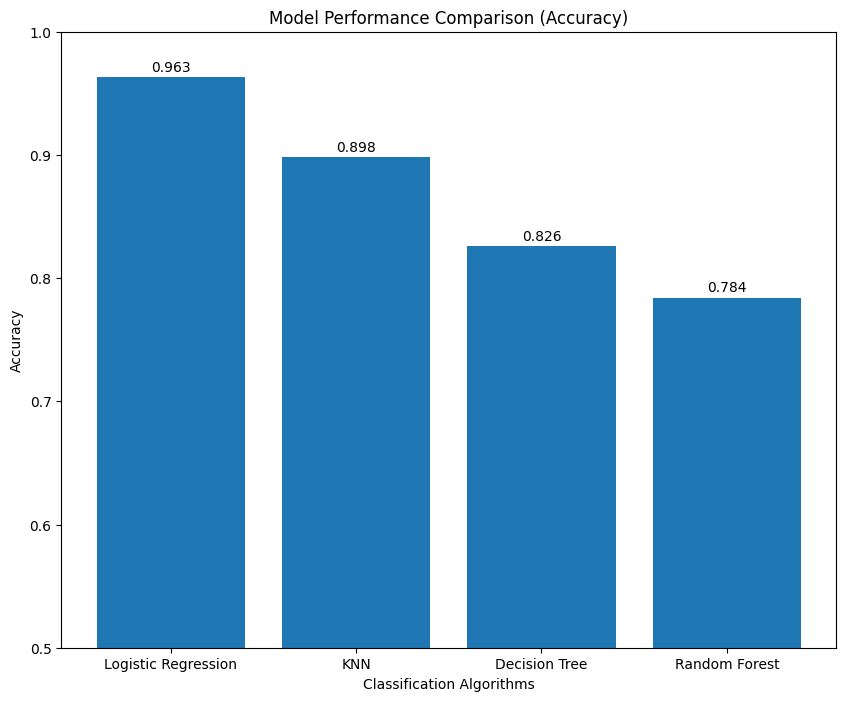

In [46]:
import matplotlib.pyplot as plt

# Model names and accuracies
models = [
    "Logistic Regression",
    "KNN",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    0.963, # LR
    0.898, # KNN
    0.826, #DT
    0.784 #RF
]

# Create bar chart
plt.figure(figsize=(10,8))
plt.bar(models, accuracies)
plt.xlabel("Classification Algorithms")
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison (Accuracy)")
plt.ylim(0.5, 1.0)

# Add accuracy labels on bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f"{acc:.3f}", ha='center')

plt.show()


### Custom vs Library Implementation — Performance Comparison

| Algorithm               | Custom Implementation Accuracy | scikit-learn Accuracy | Difference | Key Reason                                              |
| ----------------------- | ------------------------------ | --------------------- | ---------- | ------------------------------------------------------- |
| **Logistic Regression** | **0.963**                      | **0.996**             | ↓ 0.033    | Simplified gradient descent, no advanced optimization   |
| **K-Nearest Neighbors** | **0.898**                      | **0.905**             | ↓ 0.007    | Minor implementation differences, close match           |
| **Decision Tree**       | **0.826**                      | **0.855**             | ↓ 0.029    | Limited split search, no pruning, shallow depth         |
| **Random Forest**       | **0.784**                      | **0.906**             | ↓ 0.122    | Few trees, simplified feature sampling, no optimization |
